# **IMPORT LIBRARIES**

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


# **IMPORT DATASET**

In [ ]:
path = kagglehub.dataset_download("akashdeepkuila/automobile-customer")
df = pd.read_csv(f"{path}/test-set.csv")

Using Colab cache for faster access to the 'automobile-customer' dataset.


# **DATASET CLEANING AND PREPROCESSING**

In [ ]:
originaldf=df.copy()

In [ ]:
print(df.head)
print(len(df))

<bound method NDFrame.head of       CustomerID  Gender Married  Age Graduated     Profession  \
0         458989  Female     Yes   36       Yes       Engineer   
1         458994    Male     Yes   37       Yes     Healthcare   
2         458996  Female     Yes   69        No            NaN   
3         459000    Male     Yes   59        No      Executive   
4         459001  Female      No   19        No      Marketing   
...          ...     ...     ...  ...       ...            ...   
2622      467954    Male      No   29        No     Healthcare   
2623      467958  Female      No   35       Yes         Doctor   
2624      467960  Female      No   53       Yes  Entertainment   
2625      467961    Male     Yes   47       Yes      Executive   
2626      467968  Female      No   43       Yes     Healthcare   

      WorkExperience SpendingScore  FamilySize    Category  
0                0.0           Low         1.0  Category 6  
1                8.0       Average         4.0  Categor

In [ ]:
df.drop('CustomerID', axis=1, inplace=True)
df.drop('Category', axis=1, inplace=True)

the features `CustomerID` and `Category` were removed as they were deemed irrelevant for the clustering task

In [ ]:
print(df.isnull().sum())

Gender              0
Married            50
Age                 0
Graduated          24
Profession         38
WorkExperience    269
SpendingScore       0
FamilySize        113
dtype: int64


In [ ]:
df=df.dropna()
df=df.drop_duplicates()
print(len(df))

2034


rows containing null values or duplicate entries were discarded to ensure data quality and consistency

In [ ]:
print(df.dtypes)

Gender             object
Married            object
Age                 int64
Graduated          object
Profession         object
WorkExperience    float64
SpendingScore      object
FamilySize        float64
dtype: object


In [ ]:
df['WorkExperience'] = df['WorkExperience'].astype(int)
df['FamilySize'] = df['FamilySize'].astype(int)

all numerical variables were converted to integers to unify the data formats

# **DATA SCALING**

In [ ]:
numerical_cols = ['Age', 'FamilySize']
ordinal_cols = ['SpendingScore']
ordinal_order = [['Low', 'Average', 'High']]
categorical_cols = ['Gender', 'Married', 'Graduated', 'Profession']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('ord', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    verbose_feature_names_out=False
)

`StandardScaler` and `OneHotEncoder` were selected to standardize numerical features and encode categorical variables, respectively. these operations were integrated into a single `ColumnTransformer` to create a unified and efficient preprocessing pipeline. the `SpendingScore` feature was processed using an `OrdinalEncoder` to preserve its inherent hierarchy, as treating it as a nominal categorical variable would have resulted in the loss of its ordinal relationship

# **DATA SPLIT**

In [ ]:
X_train_val, X_test = train_test_split(df, test_size=0.2, random_state=42)
X_train, X_val = train_test_split(X_train_val, test_size=0.25, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# **DIMENSIONAL REDUCTION**

In [ ]:
latent_dim = 2                         #the number of dimensions to which the dataset will be reduced
input_dim = X_train_processed.shape[1] #size of the original dataset

**PCA**

In [ ]:
pca = PCA(n_components=latent_dim)
pca.fit(X_train_processed)

X_train_pca = pca.transform(X_train_processed)
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

**AUTOENCODER**

In [ ]:
input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)

bottleneck = Dense(latent_dim, activation='linear', name="bottleneck")(encoded)

decoded = Dense(16, activation='relu')(bottleneck)
decoded = Dense(32, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = autoencoder.fit(
    X_train_processed, X_train_processed,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_processed, X_val_processed),
    callbacks=[early_stopping],
    verbose=1
)

encoder_model = Model(input_layer, bottleneck)

X_train_ae = encoder_model.predict(X_train_processed)
X_val_ae = encoder_model.predict(X_val_processed)
X_test_ae = encoder_model.predict(X_test_processed)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3063 - val_loss: 0.2352
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2127 - val_loss: 0.1885
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1687 - val_loss: 0.1650
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1527 - val_loss: 0.1372
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1254 - val_loss: 0.1124
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1128 - val_loss: 0.1063
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1067 - val_loss: 0.1022
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1010 - val_loss: 0.0982
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0981 - val_loss: 0.0948
Epoch 10/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0944 - val_loss: 0.0918
Epoch 11/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0894 - val_loss: 0.0889
Epoch 12/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

# **OPTIMAL K SEARCH**

Analysis for k's choice on original data:


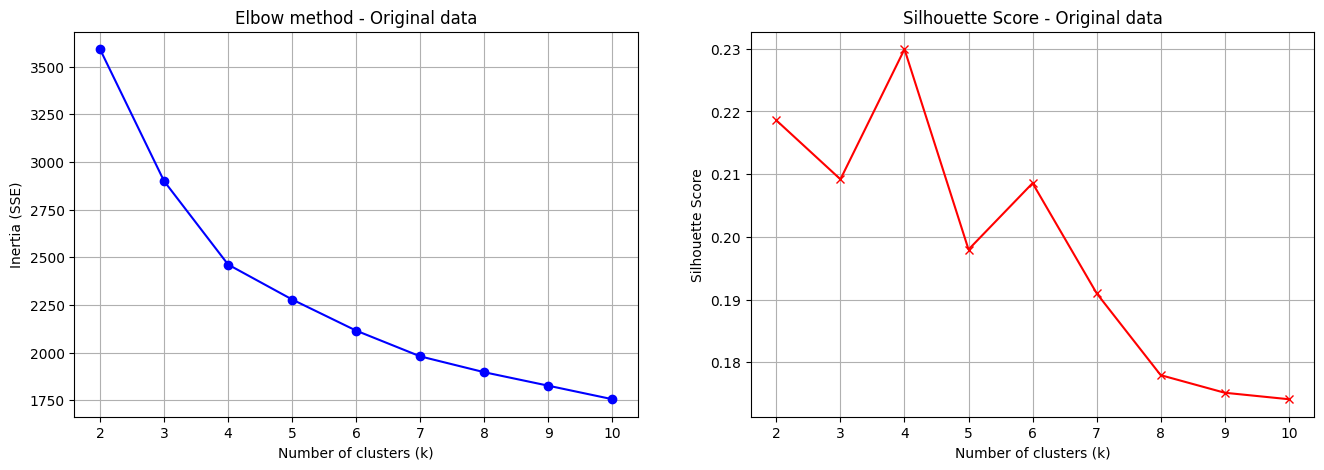

Analysis for k's choice on PCA reducted data


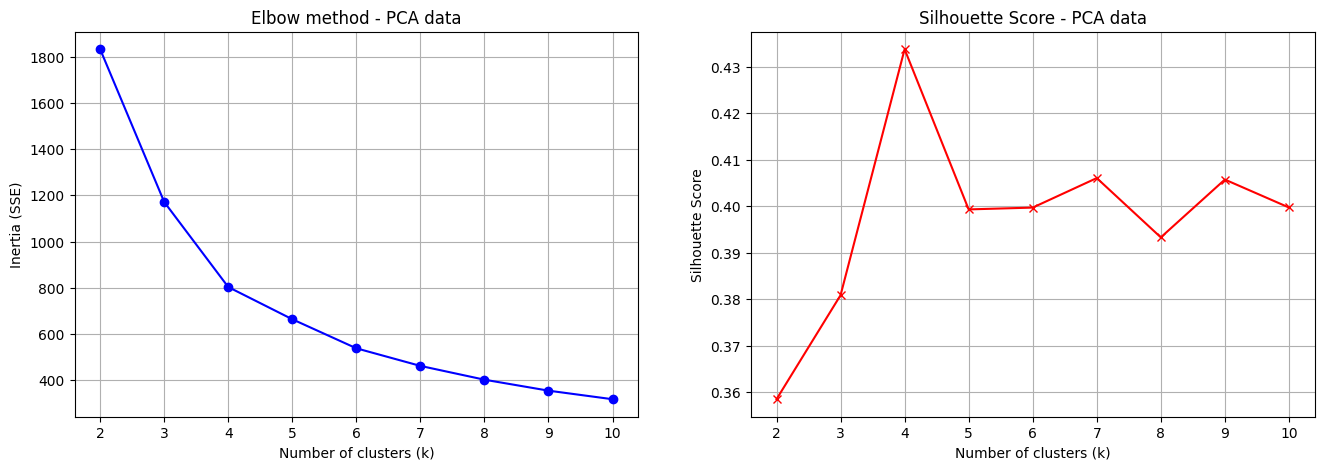

Analysis for k's choice on Autoencoding reducted data


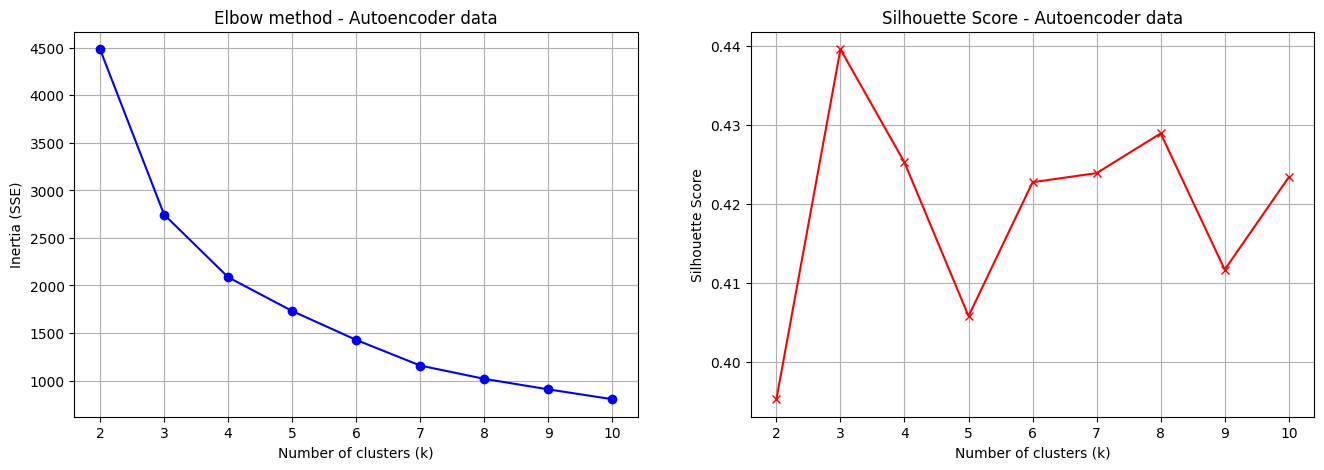

In [ ]:
def optimal_k(data, max_k=10, title=""):
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)

        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(data, kmeans.labels_))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    #ELBOW METHOD
    ax1.plot(K_range, inertias, 'bo-')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia (SSE)')
    ax1.set_title(f'Elbow method - {title}')
    ax1.grid(True)

    #SILHOUETTE
    ax2.plot(K_range, silhouettes, 'rx-')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f'Silhouette Score - {title}')
    ax2.grid(True)

    plt.show()

print("Analysis for k's choice on original data:")
optimal_k(X_train_processed, title="Original data")
print("Analysis for k's choice on PCA reducted data")
optimal_k(X_train_pca, title="PCA data")
print("Analysis for k's choice on Autoencoding reducted data")
optimal_k(X_train_ae, title="Autoencoder data")

# **K-MEANS CLUSTERING**

In [ ]:
k_best = 4

**K-MEANS ON PCA**

In [ ]:
kmeans_pca = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_train_pca)

score_pca = silhouette_score(X_train_pca, labels_pca)

**K-MEANS ON AUTOENCODER**

In [ ]:
kmeans_ae = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_ae = kmeans_ae.fit_predict(X_train_ae)

score_ae = silhouette_score(X_train_ae, labels_ae)

# **RESULT COMPARISON**

In [ ]:
kmeans_orig = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_train_processed)

datasets = {
    "Original Data": (X_train_processed, labels_orig),
    "PCA":      (X_train_pca, labels_pca),
    "Autoencoder": (X_train_ae, labels_ae)
}

results_metrics = []

for name, (data, labels) in datasets.items():
    sil = silhouette_score(data, labels)
    db = davies_bouldin_score(data, labels)
    ch = calinski_harabasz_score(data, labels)

    results_metrics.append({
        "Model": name,
        "Silhouette": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    })

df_results = pd.DataFrame(results_metrics).set_index("Model")
display(df_results)

,Silhouette,Davies-Bouldin,Calinski-Harabasz
Model,,,
Original Data,0.229925,1.399776,373.530738
PCA,0.433781,0.788809,1093.477652
Autoencoder,0.425300,0.832137,1058.060425


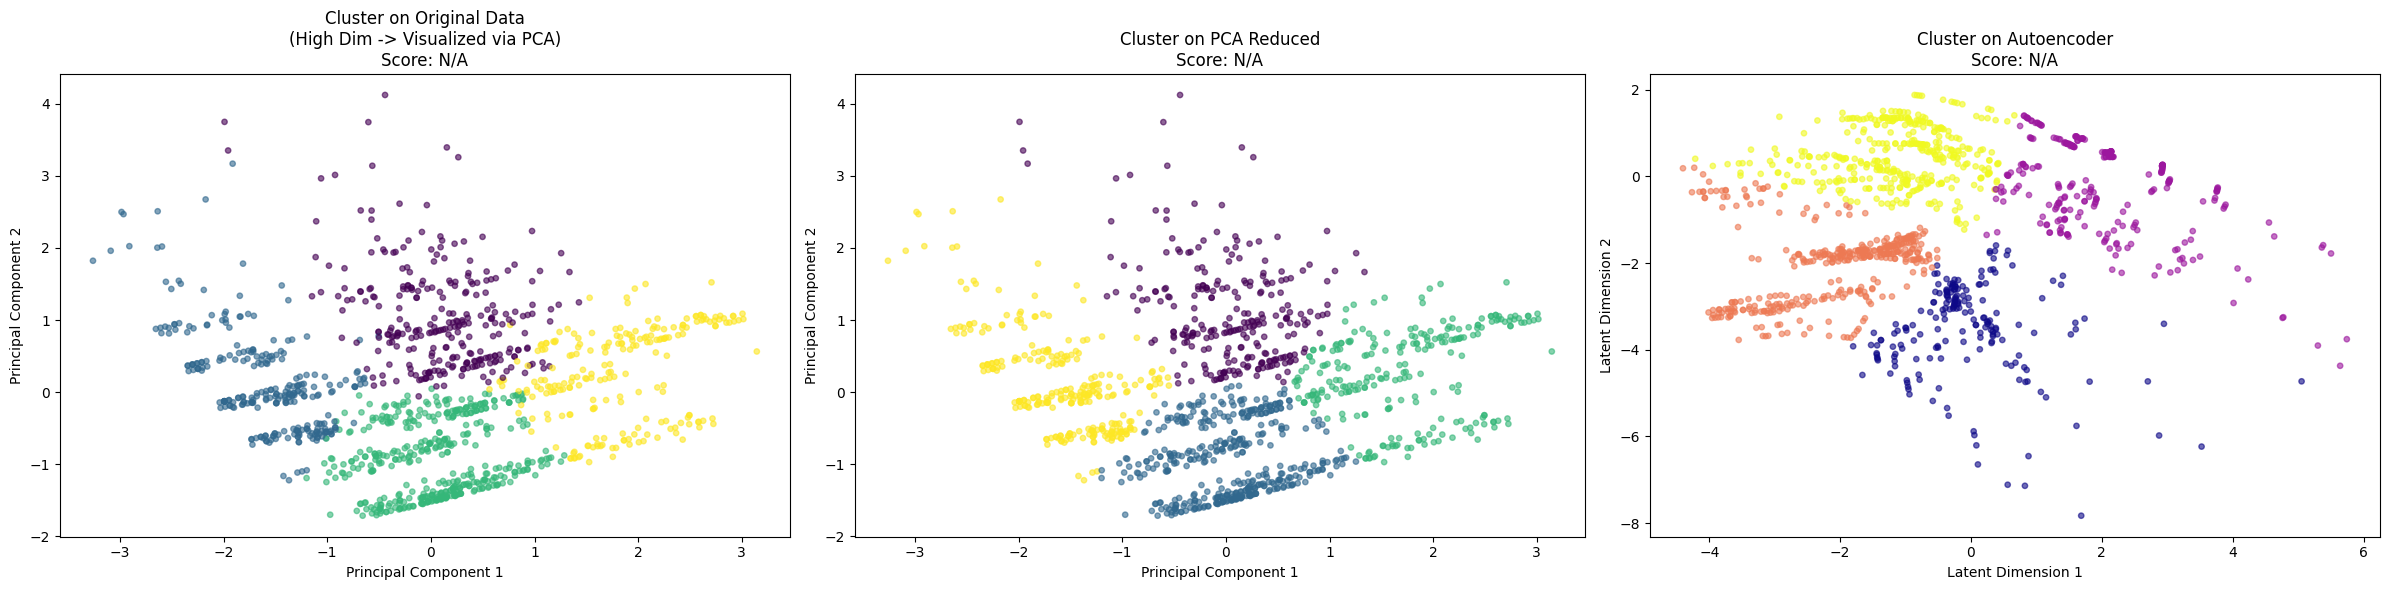

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=labels_orig, cmap='viridis', s=15, alpha=0.6)
try:
    score_orig = df_results.loc['Original Data', 'Silhouette (Test)']
    axes[0].set_title(f'Cluster on Original Data\n(High Dim -> Visualized via PCA)\nSilhouette: {score_orig}')
except:
    axes[0].set_title('Cluster on Original Data\n(High Dim -> Visualized via PCA)\nScore: N/A')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=labels_pca, cmap='viridis', s=15, alpha=0.6)
try:
    score_pca = df_results.loc['PCA (2D)', 'Silhouette (Test)']
    axes[1].set_title(f'Cluster on PCA Reduced\n(2 Dimensions)\nSilhouette: {score_pca}')
except:
    axes[1].set_title('Cluster on PCA Reduced\nScore: N/A')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

axes[2].scatter(X_train_ae[:, 0], X_train_ae[:, 1], c=labels_ae, cmap='plasma', s=15, alpha=0.6)
try:
    score_ae = df_results.loc['Autoencoder (2D)', 'Silhouette (Test)']
    axes[2].set_title(f'Cluster on Autoencoder\n(Latent Space)\nSilhouette: {score_ae}')
except:
    axes[2].set_title('Cluster on Autoencoder\nScore: N/A')
axes[2].set_xlabel('Latent Dimension 1')
axes[2].set_ylabel('Latent Dimension 2')

plt.tight_layout()
plt.show()